In [28]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem

In [29]:
Chem.Draw.IPythonConsole.molSize = (700, 700)
Chem.Draw.IPythonConsole.ipython_useSVG = True

# Ligands From CSD

In [30]:
# load the dataset
# df = pd.read_csv('ligands_csd.csv')
df = pd.read_csv('ligands_csd.csv')

In [31]:
print(f"Total number of ligands: {len(df)}")

Total number of ligands: 106519


In [32]:
df.iloc[100]

lig_mol2string       @<TRIPOS>MOLECULE\nligand_1\n    30    34     ...
lig_classify_dict    {'is_sandwich': False, 'sand_ring_sizes': [], ...
lig_charge                                                          -2
lig_smiles                        [SiH2-]c1ccccc1[SiH2]c1ccccc1[SiH2-]
lig_bind_inds                                                      NaN
metal                                                               Ni
lig_id                                            157699155000000000.0
Name: 100, dtype: object

## Subselect Neutral Ligands

In [33]:
neutral_ligands = df[df.lig_charge == 0]
print(f"Total number of neutral ligands: {len(neutral_ligands)}")

Total number of neutral ligands: 52522


## Subselect Ligands with SC Metals 

In [34]:
scmetals_ligands = df[df.metal=='Fe'].reset_index(drop=True) 
for m in ('Mn', 'Co', 'Cr'):
    scmetals_ligands = pd.concat([scmetals_ligands, df[df.metal==m]]).reset_index(drop=True)
print(f"Total number of neutral ligands: {len(scmetals_ligands)}")

Total number of neutral ligands: 22741


In [35]:
scmetals_ligands

,lig_mol2string,lig_classify_dict,lig_charge,lig_smiles,lig_bind_inds,metal,lig_id
0,@<TRIPOS>MOLECULE\nligand_0\n 91 93 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",0,NaN,[],Fe,6.733568e+39
1,@<TRIPOS>MOLECULE\nligand_2\n 14 14 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",-1,[C-]#Cc1ccccc1,[0],Fe,3.979979e+08
2,@<TRIPOS>MOLECULE\nligand_1\n 15 16 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",0,C#Cc1ccccc1,"[0, 1]",Fe,4.006889e+08
3,@<TRIPOS>MOLECULE\nligand_2\n 24 24 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",0,CC(C)(C)c1ccncc1,[7],Fe,6.822247e+09
4,@<TRIPOS>MOLECULE\nligand_3\n 34 36 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",0,CN1CCN(C)CCN(C)CC1,"[1, 4, 8]",Fe,1.347336e+09
...,...,...,...,...,...,...,...
22736,@<TRIPOS>MOLECULE\nligand_5\n 59 60 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",-2,CC(C)[Si](OC1C[C-2]NC2COC(C)(C)OC12)(C(C)C)C(C)C,[7],Cr,3.382284e+25
22737,@<TRIPOS>MOLECULE\nligand_0\n 42 49 ...,"{'is_sandwich': True, 'sand_ring_sizes': [6], ...",0,COc1cccc(COC(C)=O)c1c1cccc2ccccc12,"[12, 6, 5, 4, 3, 2]",Cr,1.214566e+25
22738,@<TRIPOS>MOLECULE\nligand_0\n 27 27 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",-2,CN([C-2]C#C)C1CCCCC1,[2],Cr,8.164648e+09
22739,@<TRIPOS>MOLECULE\nligand_5\n 34 35 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",-2,CCN([C-2]C#Cc1ccccc1)c1ccccc1,[3],Cr,2.615404e+19


## Subselect with MGT rules

In [36]:
import ast
ast.literal_eval(df.iloc[100]['lig_classify_dict'])

{'is_sandwich': False,
 'sand_ring_sizes': [],
 'sand_n_coord_atoms_per_ring': '',
 'sand_coord_atom_symbols_per_ring': '',
 'sand_ring_angles_to_metals': '',
 'sand_ring_dists_to_metals': '',
 'is_edge': True,
 'edge_n_coordinated': 2,
 'edge_coord_atom_symbols': 'H,Si',
 'coordinated_metal_syms': 'Ni',
 'ligand_types': 'edge',
 'ligand_coord_atom_symbols': 'H,Si',
 'ligand_denticities': '4',
 'ligand_type_probabilites': [{}],
 'ligand_prob_ratios': '100',
 'ligand_geo_vects': '[]'}

In [37]:
allowable_denticites=[1,2,3,6]
possible_ligs_ids = []
for i in range(len(df)):
    ch = df.iloc[i]['lig_charge']
    temp_dict = ast.literal_eval(df.iloc[i]['lig_classify_dict'])
    if not bool(temp_dict['is_sandwich']) and not bool(temp_dict['is_edge']):
        if (int(temp_dict['ligand_denticities']) in allowable_denticites) and (
            ((ch * int(6/int(temp_dict['ligand_denticities']))) + 2) > -3):
                possible_ligs_ids.append(i)

    

In [38]:
mgt_df = df.iloc[possible_ligs_ids].reset_index()

In [39]:
len(mgt_df)

56582

In [40]:
mgt_df_clean = mgt_df.dropna(subset=['lig_smiles', 'lig_bind_inds']).reset_index(drop=True)

In [41]:
len(mgt_df_clean)

51366

In [42]:
mgt_df_clean.head(5)

,index,lig_mol2string,lig_classify_dict,lig_charge,lig_smiles,lig_bind_inds,metal,lig_id
0,1,@<TRIPOS>MOLECULE\nligand_1\n 4 3 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",0,O,[0],Ni,1.620358e+01
1,4,@<TRIPOS>MOLECULE\nligand_0\n 20 20 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",-1,CSC([NH-])=NN=C(C)C,"[5, 3]",Co,1.961082e+09
2,6,@<TRIPOS>MOLECULE\nligand_1\n 4 3 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",0,O=N=O,[1],Co,3.424650e+03
3,9,@<TRIPOS>MOLECULE\nligand_0\n 66 70 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",-1,CC(C)c1cccc(C(C)C)c1[N-]C(C)(C)c1cccc(n1)c1ccc...,"[21, 12]",Al,3.517699e+34
4,10,@<TRIPOS>MOLECULE\nligand_0\n 75 79 ...,"{'is_sandwich': False, 'sand_ring_sizes': [], ...",-1,CC(C)c1cc(C(C)C)c([N-]C(C)(C)c2cccc(n2)c2cccc3...,"[19, 10]",Al,6.069181e+37


In [43]:
mgt_df_clean.to_csv('ligands_csd_rules.csv', index=False)

In [47]:
mgt_df_clean['mol'] = mgt_df_clean['lig_smiles'].apply(Chem.MolFromSmiles)

[10:03:03] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:03:03] Explicit valence for atom # 7 B, 5, is greater than permitted
[10:03:03] Explicit valence for atom # 5 B, 5, is greater than permitted
[10:03:03] Explicit valence for atom # 9 B, 4, is greater than permitted
[10:03:03] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 12
[10:03:03] Explicit valence for atom # 5 B, 5, is greater than permitted
[10:03:03] Explicit valence for atom # 1 B, 4, is greater than permitted
[10:03:03] Explicit valence for atom # 6 B, 4, is greater than permitted
[10:03:03] Explicit valence for atom # 6 N, 4, is greater than permitted
[10:03:03] Explicit valence for atom # 6 B, 4, is greater than permitted
[10:03:03] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:03:03] Explicit valence for atom # 11 B, 5, is greater than permitted
[10:03:03] Explicit valence for atom # 6 B, 4, is greater than permitted
[10:03:03] Explicit valence for atom # 1 O, 3, is greater tha

In [50]:
n_total = len(mgt_df_clean)
n_valid = mgt_df_clean['mol'].notnull().sum()
n_invalid = mgt_df_clean['mol'].isnull().sum()

print(f"Total molecules: {n_total}")
print(f"Valid molecules: {n_valid}")
print(f"Invalid molecules: {n_invalid}")

invalid_smiles = mgt_df_clean[mgt_df_clean['mol'].isnull()]
invalid_smiles.to_csv('invalid_smiles.csv', index=False)

mgt_df_clean = mgt_df_clean[mgt_df_clean['mol'].notnull()]


Total molecules: 51366
Valid molecules: 47916
Invalid molecules: 3450


In [53]:
mgt_df_clean[['lig_smiles', 'lig_bind_inds']].to_csv('initial_ligands.csv', index=False)
mgt_df_clean[['lig_smiles', 'lig_bind_inds']].to_pickle('initial_ligands.pkl')

In [51]:
from minervachem.fingerprinters import GraphletFingerprinter
from minervachem.transformers import FingerprintFeaturizer


featurizer = FingerprintFeaturizer(
    fingerprinter=GraphletFingerprinter(max_len=5),
    verbose=0,         # Optional verbosity parameter
    # Parallel Arguments
    n_jobs=-3,         # For joblib, this means all n_cores-2. 
    chunk_size='auto', # Optional, how many molecules each core should do in a batch.
)

X_lig_feat = featurizer.fit_transform(mgt_df_clean['mol'])




No elements to filter. Complete fingerprints are returned.
Number of cores used: -3


/Users/avar/anaconda3/envs/minervachem/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [52]:
from scipy import sparse
sparse.save_npz('X_lig_feat.npz', X_lig_feat)

# Visualize Ligand

In [14]:
mol = Chem.AddHs(Chem.MolFromSmiles(mgt_df_clean.iloc[4]['lig_smiles']))

In [ ]:
mgt_df_clean.iloc[4]['lig_bind_inds']


In [80]:
img = Chem.Draw.MolToImage(mol, highlightAtoms=ast.literal_eval(mgt_df_clean.iloc[4]['lig_bind_inds']))
img.show()

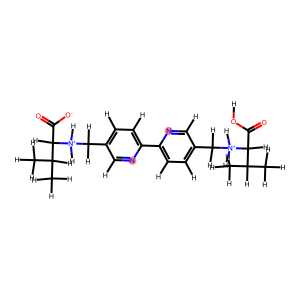

In [94]:
from rdkit.Chem import Draw

ind=300 # change index to look at different ligands

mol = Chem.AddHs(Chem.MolFromSmiles(mgt_df_clean.iloc[ind]['lig_smiles']))
mol._atomHighlights = ast.literal_eval(mgt_df_clean.iloc[ind]['lig_bind_inds'])
Draw.MolToImage(mol, highlightAtoms=ast.literal_eval(mgt_df_clean.iloc[ind]['lig_bind_inds']))


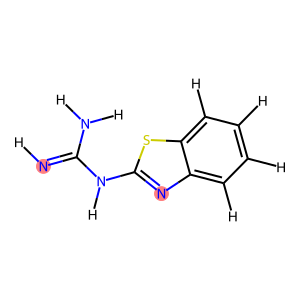

In [95]:
ind=301 # change index to look at different ligands

mol = Chem.AddHs(Chem.MolFromSmiles(mgt_df_clean.iloc[ind]['lig_smiles']))
mol._atomHighlights = ast.literal_eval(mgt_df_clean.iloc[ind]['lig_bind_inds'])
Draw.MolToImage(mol, highlightAtoms=ast.literal_eval(mgt_df_clean.iloc[ind]['lig_bind_inds']))

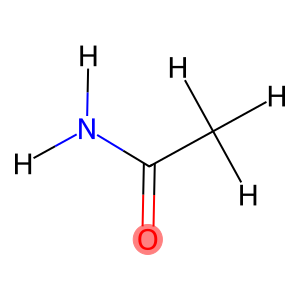

In [96]:
ind=302 # change index to look at different ligands

mol = Chem.AddHs(Chem.MolFromSmiles(mgt_df_clean.iloc[ind]['lig_smiles']))
mol._atomHighlights = ast.literal_eval(mgt_df_clean.iloc[ind]['lig_bind_inds'])
Draw.MolToImage(mol, highlightAtoms=ast.literal_eval(mgt_df_clean.iloc[ind]['lig_bind_inds']))

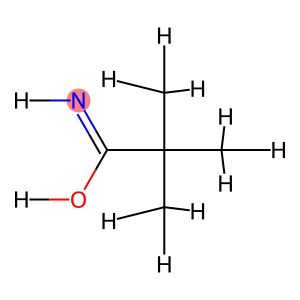

In [97]:
ind=303 # change index to look at different ligands

mol = Chem.AddHs(Chem.MolFromSmiles(mgt_df_clean.iloc[ind]['lig_smiles']))
mol._atomHighlights = ast.literal_eval(mgt_df_clean.iloc[ind]['lig_bind_inds'])
Draw.MolToImage(mol, highlightAtoms=ast.literal_eval(mgt_df_clean.iloc[ind]['lig_bind_inds']))